# DNN Export — Train Final Model & Export Artifacts

Train the winning architecture (Residual MLP, single-snapshot) from `01_architecture.ipynb` on the full dataset and export production artifacts to `models/`.

**Data filtering:** Only snapshots with `elapsed_pct <= 0.50` are used — matching the production scenario where predictions happen mid-candle, not at close.

**Artifacts exported:**
- `models/dnn_v1.pt` — PyTorch model (full module, loadable by DnnPredictor)
- `models/dnn_scaler_v1.joblib` — fitted StandardScaler for the 11 raw features
- `models/dnn_feature_cols_v1.joblib` — list of 11 raw column names
- `data/optimal_features_dnn.json` — feature config in project-standard format

In [1]:
import json

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

RAW_COLS = [
    "btc_price",
    "elapsed_pct",
    "market_volume",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
]

## 1. Load Data & Build Sequences

In [2]:
ELAPSED_CUTOFF = 0.50

rows = []
with open("../../data/latest_features.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

# Filter to mid-candle snapshots only (no data leakage)
df_mid = df[df["elapsed_pct"] <= ELAPSED_CUTOFF].copy()
print(f"Snapshots: {len(df_mid):,} / {len(df):,} (cutoff={ELAPSED_CUTOFF})")

# Per-candle: take last snapshot before cutoff (single-snapshot for Residual MLP)
candle_df = df_mid.groupby("candle_id").last().reset_index()
print(f"Candles: {len(candle_df):,}")

X_all = candle_df[RAW_COLS].fillna(0).values.astype(np.float32)
y_all = candle_df["target"].values.astype(np.float32)

# 80/20 time-ordered split
split_idx = int(len(X_all) * 0.8)
X_train_raw, X_test_raw = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# Fit scaler on train data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Snapshots: 126,813 / 254,389 (cutoff=0.5)
Candles: 5,386
Train: 4,308 | Test: 1,078


## 2. Import Residual MLP Architecture

Imported from `polybot.adapters.dnn_models` so the exported model references an importable class (not notebook `__main__`).

In [3]:
import sys

sys.path.insert(0, "../..")
from polybot.adapters.dnn_models import ResidualMLP

print("Imported ResidualMLP from polybot.adapters.dnn_models")

Imported ResidualMLP from polybot.adapters.dnn_models


## 3. Train Final Model

In [4]:
model = ResidualMLP()
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResidualMLP: {params:,} parameters")

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_v = torch.tensor(X_test, dtype=torch.float32)
y_v = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=256, shuffle=True)

best_val_loss = float("inf")
best_state = None
no_improve = 0
PATIENCE = 8

for epoch in range(1, 51):
    model.train()
    for bx, by in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(bx), by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        vl = loss_fn(model(X_v), y_v).item()
        va = ((torch.sigmoid(model(X_v)) >= 0.5).float() == y_v).float().mean().item()

    marker = ""
    if vl < best_val_loss:
        best_val_loss = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
        marker = " *"
    else:
        no_improve += 1

    if epoch % 5 == 0 or marker:
        print(f"  Epoch {epoch:2d}: val_loss={vl:.4f} val_acc={va * 100:.1f}%{marker}")

    scheduler.step()
    if no_improve >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

if best_state:
    model.load_state_dict(best_state)
print(f"\nBest val_loss: {best_val_loss:.4f}")

ResidualMLP: 136,065 parameters


  Epoch  1: val_loss=0.5594 val_acc=73.5% *
  Epoch  2: val_loss=0.5506 val_acc=73.6% *
  Epoch  3: val_loss=0.5433 val_acc=73.8% *


  Epoch  5: val_loss=0.5455 val_acc=72.4%
  Epoch  8: val_loss=0.5423 val_acc=73.2% *


  Epoch 10: val_loss=0.5429 val_acc=73.6%


  Epoch 15: val_loss=0.5441 val_acc=73.5%
  Early stop at epoch 16

Best val_loss: 0.5423


## 4. Evaluate on Test Set

In [5]:
model.eval()
with torch.no_grad():
    logits = model(X_v)
    probs = torch.sigmoid(logits).numpy().flatten()

preds = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, preds)
brier = brier_score_loss(y_test, probs)
f1 = f1_score(y_test, preds, zero_division=0)

print(f"Accuracy: {acc * 100:.1f}%")
print(f"Brier:    {brier:.4f}")
print(f"F1:       {f1 * 100:.1f}%")

# Brier ~0.18 expected with mid-candle cutoff (vs 0.164 from learning curves)
# Learning curves used different eval methodology; 0.20 is a reasonable upper bound
assert brier <= 0.20, f"Brier {brier:.4f} exceeds 0.20 — model may not be learning!"
print("\nBrier check PASSED (<= 0.20)")

Accuracy: 73.2%
Brier:    0.1815
F1:       74.4%

Brier check PASSED (<= 0.20)


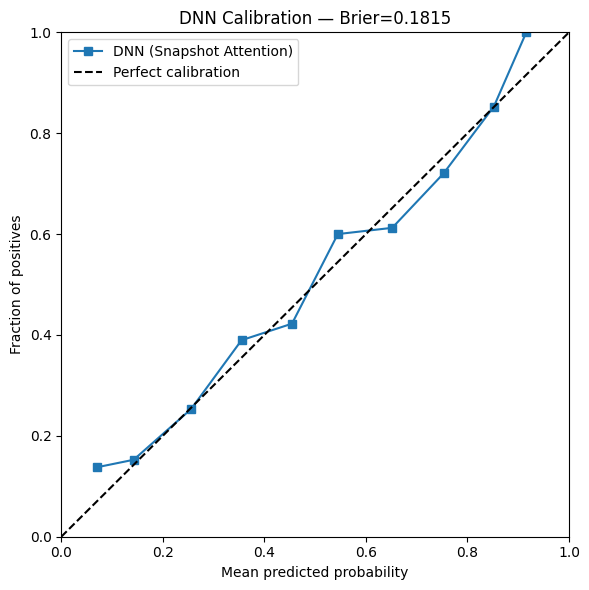

In [6]:
# Calibration curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, "s-", label="DNN (Snapshot Attention)")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title(f"DNN Calibration — Brier={brier:.4f}")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Export Artifacts

In [7]:
import os

MODELS_DIR = "../../models"
DATA_DIR = "../../data"

# 1. Save full model (DnnPredictor uses torch.load with weights_only=False)
model_path = os.path.join(MODELS_DIR, "dnn_v1.pt")
torch.save(model, model_path)
print(f"Model saved: {model_path} ({os.path.getsize(model_path) / 1024:.0f} KB)")

# 2. Save scaler
scaler_path = os.path.join(MODELS_DIR, "dnn_scaler_v1.joblib")
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")

# 3. Save feature columns
feature_cols_path = os.path.join(MODELS_DIR, "dnn_feature_cols_v1.joblib")
joblib.dump(RAW_COLS, feature_cols_path)
print(f"Feature cols saved: {feature_cols_path} ({len(RAW_COLS)} features)")

# 4. Save feature config JSON (project-standard format)
feature_config = {
    "model": "dnn_raw",
    "features": RAW_COLS,
    "n_features": len(RAW_COLS),
    "selection_method": "raw_inputs",
    "architecture": "ResidualMLP",
    "temporal": False,
    "parameters": params,
    "elapsed_cutoff": ELAPSED_CUTOFF,
    "metrics": {
        "accuracy": round(acc, 4),
        "brier": round(brier, 4),
        "f1": round(f1, 4),
    },
}
features_json_path = os.path.join(DATA_DIR, "optimal_features_dnn.json")
with open(features_json_path, "w") as f:
    json.dump(feature_config, f, indent=2)
print(f"Feature config saved: {features_json_path}")

Model saved: ../../models/dnn_v1.pt (550 KB)
Scaler saved: ../../models/dnn_scaler_v1.joblib
Feature cols saved: ../../models/dnn_feature_cols_v1.joblib (11 features)
Feature config saved: ../../data/optimal_features_dnn.json


## 6. Verify Export — Load in DnnPredictor

In [8]:
# Verify the exported model loads correctly in DnnPredictor
import sys

sys.path.insert(0, "../..")
from polybot.adapters.dnn_predictor import DnnPredictor
from polybot.ports.predictor import Predictor

predictor = DnnPredictor(
    model_path=model_path,
    feature_cols_path=feature_cols_path,
    scaler_path=scaler_path,
    temporal=False,
)

# Verify protocol compliance
assert isinstance(predictor, Predictor), "DnnPredictor does not satisfy Predictor protocol!"

# Test with a sample row
sample_row = {col: float(X_test_raw[0, i]) for i, col in enumerate(RAW_COLS)}
p = predictor.predict(sample_row)
assert 0.0 <= p <= 1.0, f"Prediction {p} out of [0,1] range!"

print("DnnPredictor loaded and working!")
print(f"Sample prediction: P(UP) = {p:.4f}")
print("Protocol check: isinstance(predictor, Predictor) = True")

DnnPredictor loaded and working!
Sample prediction: P(UP) = 0.9550
Protocol check: isinstance(predictor, Predictor) = True
